# 1. Libraries

In [1]:
import pandas as pd
import numpy as np
import gensim
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
import matplotlib.pyplot as plt
import util
import ast
import os
import random
from scipy.stats import variation
from sklearn.metrics.pairwise import cosine_similarity
from heapq import heappush, heappop, heapify
import seaborn as sns
import gc


# 2. Helper functions

In [2]:
def cosine_similarity_adapter(x, y):
    """ 
    Calcs the cosine similarity between two vectors
    """
    return cosine_similarity(x.reshape(1, -1), y.reshape(1, -1))[0][0]

def encode(symb2freq):
    """Huffman encode the given dict mapping symbols to weights"""
    heap = [[wt, [sym, ""]] for sym, wt in symb2freq.items()]
    heapify(heap)
    while len(heap) > 1:
        lo = heappop(heap)
        hi = heappop(heap)
        for pair in lo[1:]:
            pair[1] = '0' + pair[1]
        for pair in hi[1:]:
            pair[1] = '1' + pair[1]
        heappush(heap, [lo[0] + hi[0]] + lo[1:] + hi[1:])
    return sorted(heappop(heap)[1:], key=lambda p: (len(p[-1]), p))

def huff(symb2freq):
    huffmansymbols = ""
    huffw = encode(symb2freq)
    for p in huffw:
        huffmansymbols += p[1] * symb2freq[p[0]]
    huff = len(huffmansymbols) / 8
    return huff

def calculate_density(df):
    """
    Calculate the huffman coding bit size of the normalized text of the df
    """
    words = []
    for s in df['normalized_text']:
        for w in ast.literal_eval(s):
            words.append(w)
    
    symb2freq = {}
    for word in words:
        if word in symb2freq:
            symb2freq[word] += 1
        else:
            symb2freq[word] = 1

    return huff(symb2freq)

def dist_and_cv_wv(model):
    """
    Calculates the average sim and coeff of var for 10,000 random pairs of words
        Inputs: 
            - model (word2vec model): a model trained on a president corpus

        Outputs:
            - mean_dist (float): the mean cosine similarity of the 10,000 pairs
            - cv (float): the coefficient of variation of the 10,000 pairs
    """
    distances = []
    word_indexes = len(model.wv.key_to_index.keys()) - 1
    for i in range(10000): 
        rand1 = model.wv.index_to_key[random.randrange(0, word_indexes)]
        rand2 = model.wv.index_to_key[random.randrange(0, word_indexes)]
        dist = model.wv.similarity(rand1, rand2)
        distances.append(dist)
        
    mean_dist = float(sum(distances)) / float(len(distances))
    cv        = variation(distances)

    return mean_dist, cv

def dist_and_cv_dv(model):
    """
    Calculates the average sim and coeff of var for 10,000 random pairs of docs
        Inputs: 
            - model (word2vec model): a model trained on a president corpus

        Outputs:
            - mean_dist (float): the mean cosine similarity of the 10,000 pairs
            - cv (float): the coefficient of variation of the 10,000 pairs
    """
    distances = []
    doc_indexes = len(model.dv.key_to_index.keys()) - 1
    for i in range(10000): 
        rand1 = model.dv.index_to_key[random.randrange(0, doc_indexes)]
        rand2 = model.dv.index_to_key[random.randrange(0, doc_indexes)]
        dist = model.dv.similarity(rand1, rand2) + 1
        distances.append(dist)
        
    mean_dist = float(sum(distances)) / float(len(distances))
    cv        = variation(distances)

    return mean_dist, cv

def assign_ideology(president):
    """
    Assigns a president an ideology
    """
    left = ['morales', 'correa', 'sanchez', 'funes', 'maduro', 'chavez']
    center_left = ['kichner', 'bachelet', 'solis', 'colom', 'ortega', 'ollanta', 'lugo', 'tabare', 'mujica']
    center_right = ['chinchilla', 'arias', 'medina', 'fernandez', 'zelaya', 'pena_nieto', 'alan']

    if president in left:
        return 'left'
    elif president in center_left:
        return 'center_left'
    elif president in center_right:
        return 'center_right'
    else:
        return 'right'
    
def assign_populist(president):
    """
    Labels presidents as populist or not
    """
    populist = ['chavez', 'maduro', 'ortega', 'correa', 'morales', 'kirchner', 'uribe']
    if president in populist:
        return 'populist'
    else:
        return 'not_populist'
    
def create_scatter(ax, pol_var, density_var):
    sns.scatterplot(data=density, x=pol_var, y=density_var, ax=ax)
    for i in range(len(density[pol_var])):
        ax.text(density[pol_var][i], density[density_var][i], density['index'][i],
                horizontalalignment='left', size='medium', color='black',
                bbox=dict(facecolor='white', alpha=0.5, edgecolor='black'))
    ax.set_title(f"{density_var} vs. {pol_var}")
    ax.set_xlabel(pol_var)
    ax.set_ylabel(density_var)

# 3. Test density of language space

density: the average amount of conceptual information per language unit.

Denser language spaces use less language units (words, sentences, etc.) to conveys meaning.

For spaces with less topics, there should a be higher density?

In [5]:

#set seed and initialize dict
file_path = r"C:\Users\asarr\Documents\Projects\pol-cul-maps-latam\president_csvs\coca"
random.seed(0)
den_dict = {}

for i, df in enumerate(os.listdir(file_path)):
    #prep
    name = df.split('.')[0]
    pres_df = pd.read_csv(f'{file_path}\{df}')

    #process    
    print(f'Working on {name}. {i+1} of 20')
    pres_df['tokenized_sents'] = pres_df['text2'].apply(lambda x: [util.word_tokenize_es(s) for s in util.sent_tokenize_es(x)])
    pres_df['normalized_sents'] = pres_df['tokenized_sents'].apply(lambda x: [util.normalizeTokens_es(s, lemma=False) for s in x])

    pres_df['normalized_sents'] = pres_df['normalized_sents'].apply(lambda x: [s for s in x if len(s) > 0])

    #avg cosine similarity: semantic density
    w2v_model = gensim.models.word2vec.Word2Vec(pres_df['normalized_sents'].sum(), sg=1, window=6)
    avg_cos_sim, cv = dist_and_cv_wv(w2v_model)

    #compile
    den_dict[name] = [avg_cos_sim, cv]

Working on arias. 1 of 20
Working on cartes. 2 of 20
Working on chavez. 3 of 20
Working on colom. 4 of 20
Working on correa. 5 of 20
Working on fenandez. 6 of 20
Working on j_morales. 7 of 20
Working on kirchner. 8 of 20
Working on lobo. 9 of 20
Working on lugo. 10 of 20
Working on macri. 11 of 20
Working on maduro. 12 of 20
Working on martinelli. 13 of 20
Working on medina. 14 of 20
Working on morales. 15 of 20
Working on mujica. 16 of 20
Working on ortega. 17 of 20
Working on perez. 18 of 20
Working on pinera. 19 of 20
Working on santos. 20 of 20
Working on solis. 21 of 20
Working on uribe. 22 of 20
Working on varela. 23 of 20


In [6]:
density = pd.DataFrame(den_dict).T
density.columns = ['avg_cos_sim_wv', 'cv_wv']
density.head()

,avg_cos_sim_wv,cv_wv
arias,0.685068,0.272853
cartes,0.732099,0.221037
chavez,0.551425,0.339616
colom,0.537194,0.336330
correa,0.869459,0.163555


### Average cosine similarity
measures semantic density

<Axes: title={'center': 'Average Cosine Similarity by President'}>

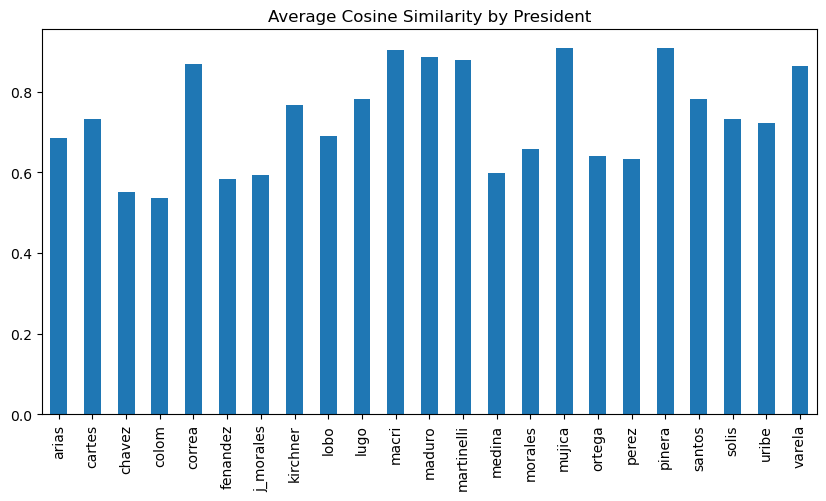

In [7]:
# graph avg_cos_sim
density['avg_cos_sim_wv'].plot(kind='bar', figsize=(10, 5), title='Average Cosine Similarity by President')

<Axes: title={'center': 'Coefficient of Variation by President'}>

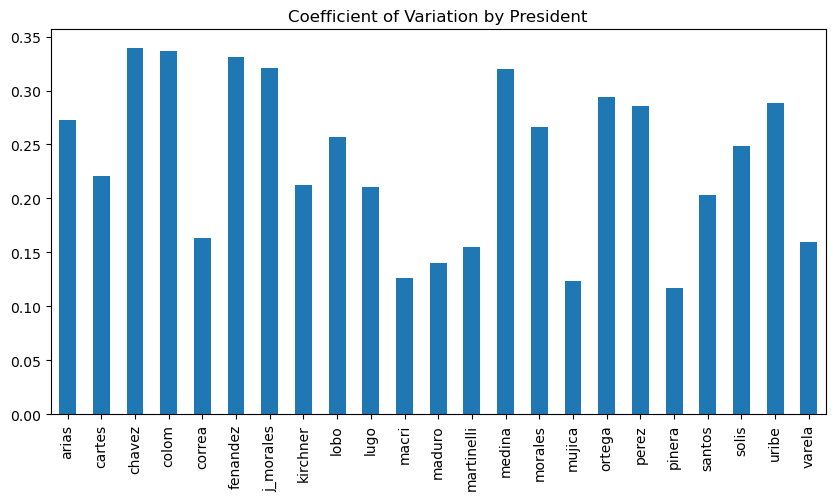

In [8]:
density['cv_wv'].plot(kind='bar', figsize=(10, 5), title='Coefficient of Variation by President')

In [9]:
#save df
density.to_csv(r"C:\Users\asarr\Documents\Projects\pol-cul-maps-latam\results\density_coca.csv")

# 4. Average semantic similarity between documents

In [11]:
file_path = r"C:\Users\asarr\Documents\Projects\pol-cul-maps-latam\president_csvs\coca"

tagged_data = []
pres_names = []

for i, df in enumerate(os.listdir(file_path)):
    #sample docs
    name = df.split('.')[0]
    pres_names.append(name)
    pres_df = pd.read_csv(f'{file_path}\{df}')
    pres_df = pres_df.sample(19)
    pres_df['normalized_text'] = pres_df['normalized_text'].apply(lambda x: ast.literal_eval(x))

    #create list of lists of tagged word
    print(f'Working on {name}. {i+1} of 20')
    tagged_data += [TaggedDocument(words=doc, tags=[name + '_' + str(i)]) for i, doc in enumerate(pres_df['normalized_text'])]

    #clean
    gc.collect()

#train model
model = Doc2Vec(vector_size=100, window=6, min_count=2, epochs = 40)
model.build_vocab(tagged_data)
model.train(tagged_data, total_examples=model.corpus_count, epochs=model.epochs)

Working on arias. 1 of 20
Working on cartes. 2 of 20
Working on chavez. 3 of 20
Working on colom. 4 of 20
Working on correa. 5 of 20
Working on fenandez. 6 of 20
Working on j_morales. 7 of 20
Working on kirchner. 8 of 20
Working on lobo. 9 of 20
Working on lugo. 10 of 20
Working on macri. 11 of 20
Working on maduro. 12 of 20
Working on martinelli. 13 of 20
Working on medina. 14 of 20
Working on morales. 15 of 20
Working on mujica. 16 of 20
Working on ortega. 17 of 20
Working on perez. 18 of 20
Working on pinera. 19 of 20
Working on santos. 20 of 20
Working on solis. 21 of 20
Working on uribe. 22 of 20
Working on varela. 23 of 20


In [12]:
cs_dict = {'President': []}

for i, vector in enumerate(model.dv.vectors):
    pres = model.dv.index_to_key[i].split('_')[0]
    cs_dict['President'].append(pres)
    row = [cosine_similarity_adapter(vector, vector2) for vector2 in model.dv.vectors]
    cs_dict[model.dv.index_to_key[i]] = row

In [13]:
df = pd.DataFrame(cs_dict)

In [14]:
presidents = df['President'].unique()
presidents

array(['arias', 'cartes', 'chavez', 'colom', 'correa', 'fenandez', 'j',
       'kirchner', 'lobo', 'lugo', 'macri', 'maduro', 'martinelli',
       'medina', 'morales', 'mujica', 'ortega', 'perez', 'pinera',
       'santos', 'solis', 'uribe', 'varela'], dtype=object)

In [15]:
#CHECKPOINT: save results
df.to_csv(r"C:\Users\asarr\Documents\Projects\pol-cul-maps-latam\results\doc2vec_coca.csv")

In [16]:
ideology = [13.27, 15.7, 2.65, 8.35, 4.2, 12.71, 10, 12.71, 17.33, 5.4, 16.24, 2.65, 17.87, 11.71, 3.44, 5.23, 8.55, 16.85, 16.33, 17.67, 6.36, 18.2, 16.88]

populism = [0,0.2375, 1.9166666, 0.125, 1.7333333, 0.25, 1, 0, 0.33333334, 0, 0.037500001, 1.6375, 0.5, 0.375, 1.4625, 0.125, 1.25, 0.34999999, 
            0.15000001, 0.0625, 0.4, 0, 0.25]

#add columns to density
density['ideology'] = ideology
density['populism'] = populism
density['index'] = density.index

In [17]:
p_id = { p: ideology[i] for i, p in enumerate(presidents)}
p_pol = { p: populism[i] for i, p in enumerate(presidents)}

In [18]:
#assign populism values to df
df['populist'] = df['President'].map(p_pol)
df['ideology'] = df['President'].map(p_id)

In [19]:
#reorder df based on populist
df_pol = df.sort_values(by=['populist', 'President'])
df_idel = df.sort_values(by=['ideology', 'President'])

done with calcs, now plotting
done with avg
done with var


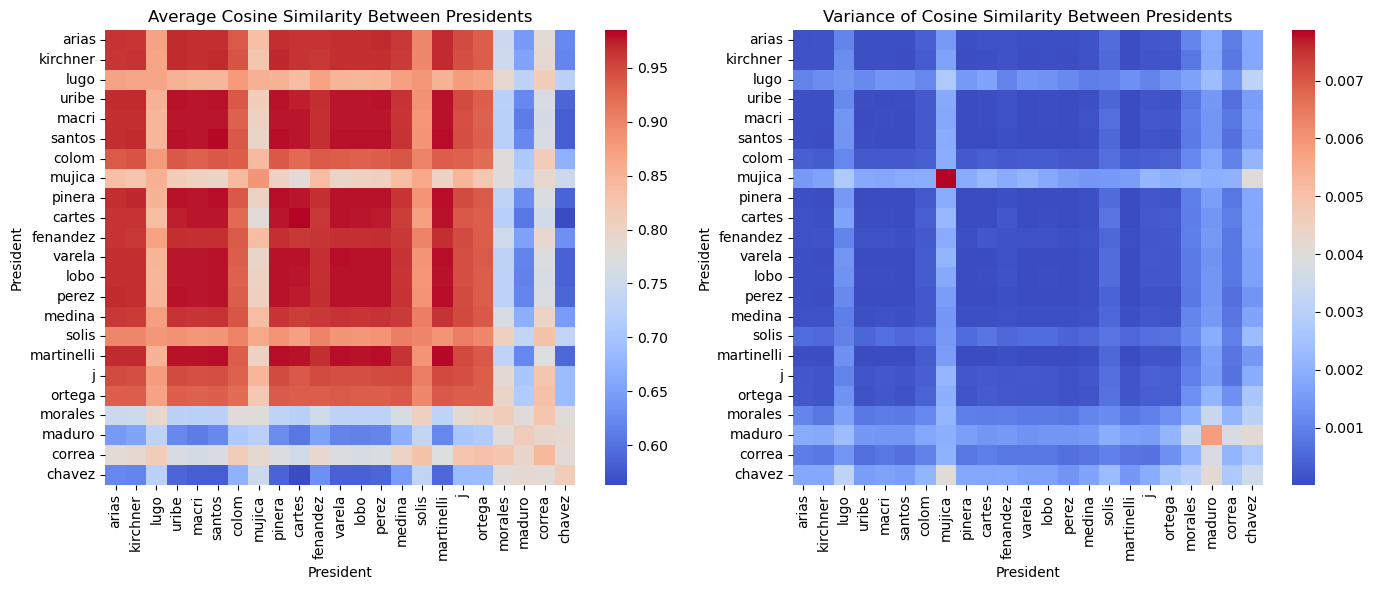

In [20]:
for column in df_pol.columns:
    if column != 'President':
        df_pol[column] = pd.to_numeric(df[column], errors='coerce')

# Get unique presidents
presidents = df_pol['President'].unique()

# Initialize matrices for average and variance
avg_similarity = pd.DataFrame(np.zeros((len(presidents), len(presidents))), index=presidents, columns=presidents)
var_similarity = pd.DataFrame(np.zeros((len(presidents), len(presidents))), index=presidents, columns=presidents)

# Calculate average and variance of cosine similarities
for pres1 in presidents:
    for pres2 in presidents:
        # Get documents for each president
        docs_pres1 = df_pol[df_pol['President'] == pres1].drop(columns=['President']).values
        docs_pres2 = df_pol[df_pol['President'] == pres2].drop(columns=['President']).values
        
        # Collect similarities between all pairs of documents from pres1 and pres2
        similarities = []
        for doc1 in docs_pres1:
            for doc2 in docs_pres2:
                if not np.array_equal(doc1, doc2):
                    similarities.append(np.dot(doc1, doc2) / (np.linalg.norm(doc1) * np.linalg.norm(doc2)))
        
        # Calculate mean and variance if there are similarities
        if similarities:
            avg_similarity.loc[pres1, pres2] = np.mean(similarities)
            var_similarity.loc[pres1, pres2] = np.var(similarities)

print('done with calcs, now plotting')

# Step 2: Create Heatmaps
plt.figure(figsize=(14, 6))

# Heatmap for Average Cosine Similarity
plt.subplot(1, 2, 1)
sns.heatmap(avg_similarity, cmap='coolwarm')
plt.title('Average Cosine Similarity Between Presidents')
plt.xlabel('President')
plt.ylabel('President')

print('done with avg')

# Heatmap for Variance of Cosine Similarity
plt.subplot(1, 2, 2)
sns.heatmap(var_similarity, cmap='coolwarm')
plt.title('Variance of Cosine Similarity Between Presidents')
plt.xlabel('President')
plt.ylabel('President')

print('done with var')

plt.tight_layout()
plt.show()

done with calcs, now plotting
done with avg
done with var


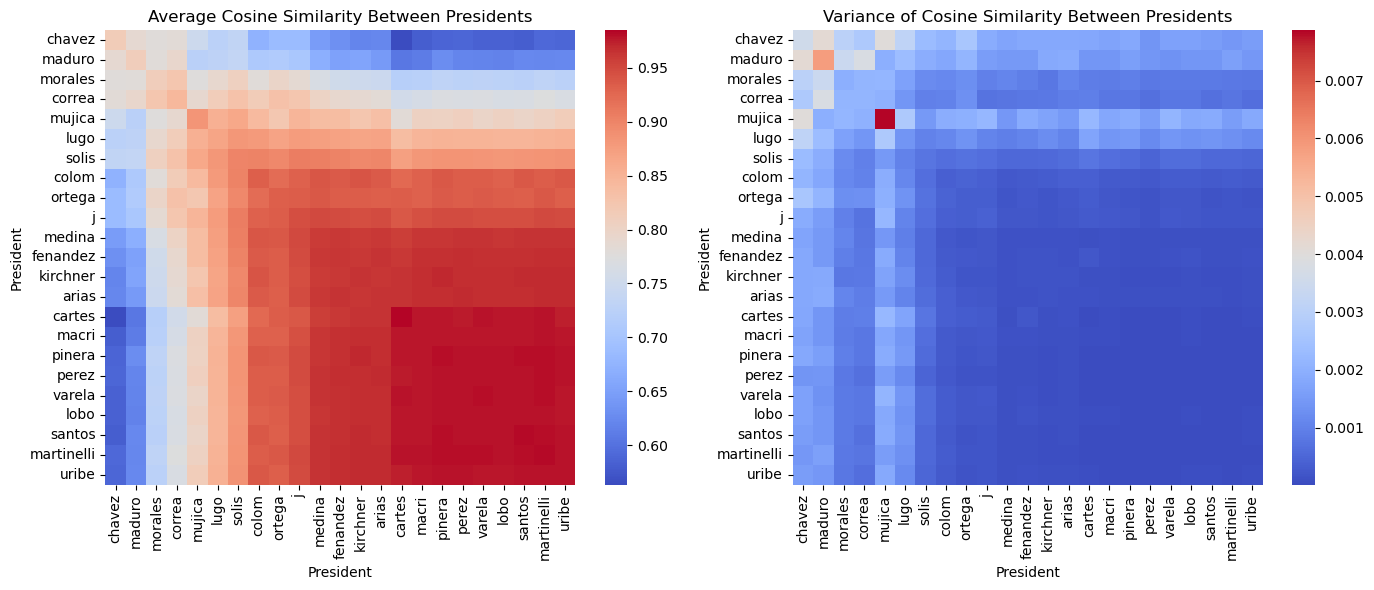

In [21]:
for column in df_idel.columns:
    if column != 'President':
        df_idel[column] = pd.to_numeric(df[column], errors='coerce')

# Get unique presidents
presidents = df_idel['President'].unique()

# Initialize matrices for average and variance
avg_similarity = pd.DataFrame(np.zeros((len(presidents), len(presidents))), index=presidents, columns=presidents)
var_similarity = pd.DataFrame(np.zeros((len(presidents), len(presidents))), index=presidents, columns=presidents)

# Calculate average and variance of cosine similarities
for pres1 in presidents:
    for pres2 in presidents:
        # Get documents for each president
        docs_pres1 = df_idel[df_idel['President'] == pres1].drop(columns=['President']).values
        docs_pres2 = df_idel[df_idel['President'] == pres2].drop(columns=['President']).values
        
        # Collect similarities between all pairs of documents from pres1 and pres2
        similarities = []
        for doc1 in docs_pres1:
            for doc2 in docs_pres2:
                if not np.array_equal(doc1, doc2):
                    similarities.append(np.dot(doc1, doc2) / (np.linalg.norm(doc1) * np.linalg.norm(doc2)))
        
        # Calculate mean and variance if there are similarities
        if similarities:
            avg_similarity.loc[pres1, pres2] = np.mean(similarities)
            var_similarity.loc[pres1, pres2] = np.var(similarities)

print('done with calcs, now plotting')

# Step 2: Create Heatmaps
plt.figure(figsize=(14, 6))

# Heatmap for Average Cosine Similarity
plt.subplot(1, 2, 1)
sns.heatmap(avg_similarity, cmap='coolwarm')
plt.title('Average Cosine Similarity Between Presidents')
plt.xlabel('President')
plt.ylabel('President')

print('done with avg')

# Heatmap for Variance of Cosine Similarity
plt.subplot(1, 2, 2)
sns.heatmap(var_similarity, cmap='coolwarm')
plt.title('Variance of Cosine Similarity Between Presidents')
plt.xlabel('President')
plt.ylabel('President')

print('done with var')

plt.tight_layout()
plt.show()

# 5. Political variables and semantic density

### Scatterplots

C:\Users\asarr\AppData\Local\Temp\ipykernel_89308\952785359.py:123: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(density[pol_var][i], density[density_var][i], density['index'][i],
C:\Users\asarr\AppData\Local\Temp\ipykernel_89308\952785359.py:123: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(density[pol_var][i], density[density_var][i], density['index'][i],


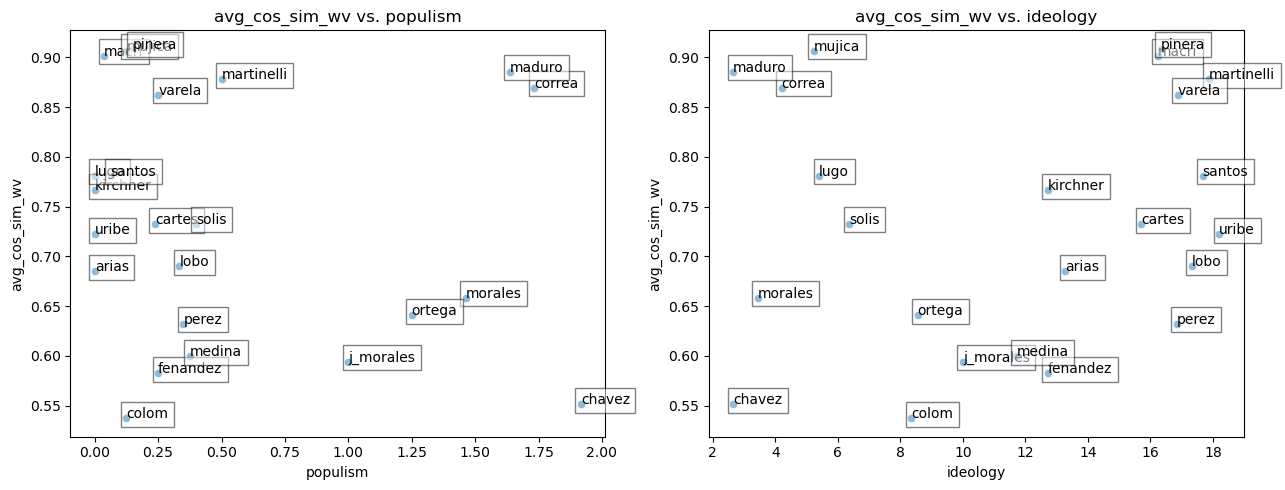

In [22]:
fig, axs = plt.subplots(1, 2, figsize=(13, 5))

create_scatter(axs[1], 'ideology', 'avg_cos_sim_wv')
create_scatter(axs[0], 'populism', 'avg_cos_sim_wv')

plt.tight_layout()
plt.show()